# Material Composition of a Typical Silicon PV Module

### Independent Research Notebook #1 — Solar Panel Recycling

To support my analysis of PV module design and recyclability, I have prepared a pie chart to depict the percentages of materials used in a standard c-Si UPV solar plant. The 6 largest contributors to the mass of a PV module are shown in the pie chart with the remaining materials included in the "Other" category. To the right, a bar graph is displayed to highlight all materials included in a standard utility c-Si PV module.

Additionally, the table below summarises five important materials used either within the module or in its supporting structure: solar glass, copper, EVA encapsulant, low‑carbon steel, and aluminum. The dataset provides a foundation for comparing their physical characteristics and implications for recycling strategies.

Material composition data is from the Renewable Energy Materials Properties Database on OpenEI through the National Renewable Energy Laboratory (NREL, 2023)(Open Energy Information, n.d.). 

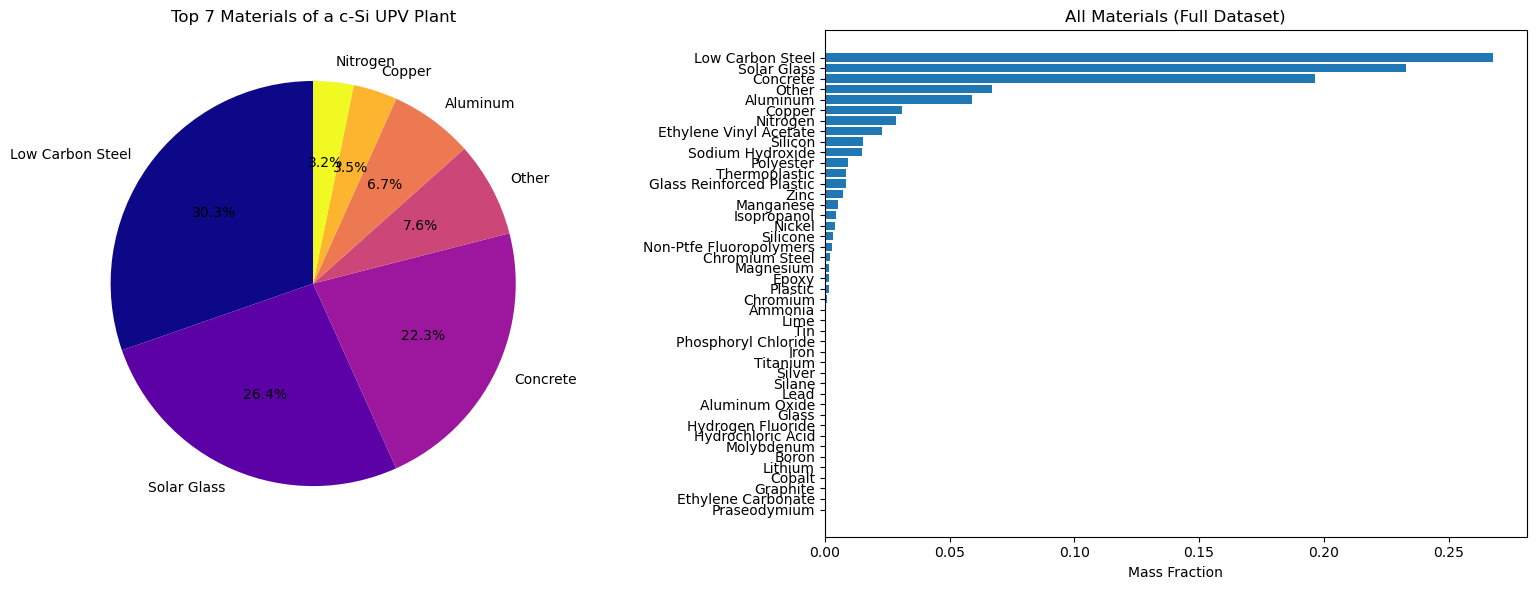

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

os.chdir(r"C:\Users\kelly\OneDrive\Desktop\solar-panel-recycling-analysis-main")
os.makedirs("results/figures", exist_ok=True)

df = pd.read_csv("data/material_composition3.csv")
df["material"] = df["material"].str.strip().str.title()
df_clean = df.groupby("material", as_index=False)["mass fraction"].sum()
df_clean = df_clean[df_clean["mass fraction"] > 1e-6]

N = 7
df_sorted = df_clean.sort_values("mass fraction", ascending=False)
df_filtered = df_sorted.head(N)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cmap = plt.cm.plasma
colors = cmap(np.linspace(0, 1, len(df_filtered)))

ax[0].pie(
    df_filtered["mass fraction"],
    labels=df_filtered["material"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90
)
ax[0].set_title(f"Top {N} Materials of a c-Si UPV Plant")

df_clean_sorted = df_clean.sort_values("mass fraction", ascending=True)

ax[1].barh(df_clean_sorted["material"], df_clean_sorted["mass fraction"])
ax[1].set_title("All Materials (Full Dataset)")
ax[1].set_xlabel("Mass Fraction")

plt.tight_layout()
plt.savefig("results/figures/materials_breakdown.png", dpi=300, bbox_inches="tight")
plt.show()


## PV Module Materials Table

This table summarises five key materials used in PV modules. Outlined are the function of each material within a solar PV module, their key properties, and recycling considerations for further analysis.”

- Solar glass[^3][^2]
- Copper[^2]  
- EVA[^2][^6]
- Low-Carbon Steel[^5]
- Aluminum[^2][^4]



In [32]:
import pandas as pd
import os

os.chdir(r"C:\Users\kelly\OneDrive\Desktop\solar-panel-recycling-analysis-main")
os.makedirs("reports", exist_ok=True)

data = {
    "Material": [
        "Solar Glass [^3][^2]",
        "Copper [^2]",
        "EVA (Encapsulant) [^2][^6]",
        "Low-Carbon Steel [^5][^9]",
        "Aluminum [^2][^4][^9]"
    ],
    "Role_in_PV_Module": [
        "Front protective layer; provides rigidity, high optical transmission, physical protection from the elements.",
        "Primary conductor in PV interconnection. Used in busbars & internal wiring. Potential to replace silver in solar cell metallization.",
        "Encapsulates and protects cells from atmospheric influences, vibrations, and humidity; bonds module layers together.",
        "Used in mounting hardware, racking, and some structural components.",
        "Commonly used for module frames due to high strength-to-weight ratio."
    ],
    "Key_Properties": [
        "Low Fe composition; Tempered for durability; Chemically stable; High transmissivity; High melting point.",
        "High strength & hardness; Great electrical and heat conductivity",
        "Durable at high temperatures; High bonding strength; Cross‑linked polymer; Flexible; Difficult to delaminate during recycling.",
        "High strength; Highly malleable & ductile; Widely recyclable with established infrastructure.",
        "Lightweight; Corrosion‑resistant; High embodied energy; Non-toxic; Excellent recyclability."
    ],
    "Recycling_Considerations": [
        "High mass but low value; EVA separation is the main barrier to recovery.",
        "Often tightly bonded to other materials, which can hinder recycling process; EVA layer is also a barrier to accessing the silicon wafer and other metals.",
        "Major barrier to recycling due to bonding and cross-linking; Requires thermal or chemical removal.",
        "Highly recyclable; Contributes to circularity in mounting systems.",
        "Using aluminum scrap can reduce CO2 emissions by 92% compared to the raw element; Easily recovered and recycled."
    ]
}

df_material_properties = pd.DataFrame(data)
df_material_properties.to_csv("results/tables/material_properties_table.csv", index=False)

with open("results/tables/material_properties_table.md", "w", encoding="utf-8") as f:
    f.write(df_material_properties.to_markdown(index=False))

df_material_properties


,Material,Role_in_PV_Module,Key_Properties,Recycling_Considerations
0,Solar Glass [^3][^2],"Front protective layer; provides rigidity, hig...",Low Fe composition; Tempered for durability; C...,High mass but low value; EVA separation is the...
1,Copper [^2],Primary conductor in PV interconnection. Used ...,High strength & hardness; Great electrical and...,"Often tightly bonded to other materials, which..."
2,EVA (Encapsulant) [^2][^6],Encapsulates and protects cells from atmospher...,Durable at high temperatures; High bonding str...,Major barrier to recycling due to bonding and ...
3,Low-Carbon Steel [^5][^9],"Used in mounting hardware, racking, and some s...",High strength; Highly malleable & ductile; Wid...,Highly recyclable; Contributes to circularity ...
4,Aluminum [^2][^4][^9],Commonly used for module frames due to high st...,Lightweight; Corrosion‑resistant; High embodie...,Using aluminum scrap can reduce CO2 emissions ...


# Markdown

## 1. Data Source & Scope

This analysis draws on the open‑source Renewable Energy Materials Properties Database developed by the National Laboratory of the Rockies. From within this dataset, I selected the c-Si UPV photovoltaic module category as the basis for my materials composition assessment. This technology class is particularly relevant in solar panel recycling research, as silicon modules account for around 95% of the current solar PV market [^7]. 

---

## 2. Data Preparation

The dataset provides component‑level material masses in kilograms per plant. To enable a consistent comparison across materials and components, I calculated mass fractions for each material using the kg_per_plant values. This was the only calculation required, and it allowed the dataset to be expressed in a normalised, module‑level format suitable for further analysis.

---

## 3. Motivation and Research Context 

Understanding the material composition of photovoltaic modules is a foundational step toward evaluating their environmental impact, long‑term sustainability, and end‑of‑life pathways. By quantifying the relative contributions of these materials, this analysis provides the basis for exploring:

 -> the feasibility and efficiency of different solar‑panel recycling strategies,

 -> the recovery potential of critical materials such as silver, copper, and silicon.

This material breakdown, therefore, serves as the analytical starting point for assessing how PV technology can evolve to support a circular, resource efficient renewable energy system. The material property data was obtained through the NREL "Physical Property Summary" dataset, along with other research articles cited below.

---

## 4. References

[^1] NREL (National Renewable Energy Laboratory) (2023) Renewable Energy Materials Properties Database, Version 1.1. Washington, D.C.: U.S. Department of Energy. Available at: https://apps.openei.org/REMPD/  (Accessed: [21 March 2026]).

[^2] Peplow, M. (2022) ‘Solar panels face a recycling challenge’, Chemical & Engineering News, 100(18). Available at: https://cen.acs.org/environment/recycling/Solar-panels-face-recycling-challenge-photovoltaic-waste/100/i18  (Accessed: [10 March 2026]).

[^3] Muniz, R., et al. (2024) ‘Glass application in solar energy technology’, ResearchGate. Available at: https://www.researchgate.net/publication/391425330_Glass_Application_in_Solar_Energy_Technology  (Accessed: [12 March 2026]).

[^4] IEA PVPS Task 12 (2020) 'End‑of‑life management of photovoltaic panels: Trends in PV module recycling technologies', International Energy Agency Photovoltaic Power Systems Programme. Available at: https://iea-pvps.org/wp-content/uploads/2020/01/End_of_Life_Management_of_Photovoltaic_Panels_Trends_in_PV_Module_Recycling_Technologies_by_task_12.pdf  (Accessed: [14 March 2026]). 

[^5] We Recycle Solar (n.d.) ‘How can solar racks be responsibly recycled?’, Available at: https://werecyclesolar.com/how-can-solar-racks-be-responsibly-recycled/  (Accessed: [17 March 2026]).

[^6] Hirschl, C., et al. (2013) ‘Determining the degree of crosslinking of ethylene vinyl acetate photovoltaic module encapsulants—A comparative study', 116, pp. 203-218. Available at: https://www.sciencedirect.com/science/article/pii/S0927024813001979/  (Accessed: [10 March 2026]).

[^7] Riech, I., et al. (2021) ‘Experimental methodology for the separation of materials in the recycling process of silicon photovoltaic panels’, Materials, 14(3). Available at: https://pmc.ncbi.nlm.nih.gov/articles/PMC7865510/  (Accessed: [13 March 2026]).

[^8] Open Energy Information (OpenEI) (n.d.) REMPD Solar Quantity Dataset. U.S. Department of Energy. Available at: https://apps.openei.org/REMPD/quantity/solar  (Accessed: [12 March 2026]). 

[^9] EuRIC AISBL (n.d.) 'Metal Recycling Factsheet', Available at: https://circulareconomy.europa.eu/platform/sites/default/files/euric_metal_recycling_factsheet.pdf  (Accessed: [22 March 2026]).